In [1]:
import spacepy.pybats as bats
import numpy as np
import scipy.constants as sc
%matplotlib ipympl

data_path = "./data/shl_var_4_n00032000.out"

data = bats.IdlFile(data_path)
print(data.keys())
print(data['r'].attrs, "\n", data['Rho'].attrs, "\n", data['Bx'].attrs)

dict_keys(['grid', 'r', 'lon', 'lat', 'Rho', 'Ux', 'Uy', 'Uz', 'Bx', 'By', 'Bz', 'Ehot', 'I01', 'I02', 'Pe', 'Ppar', 'Pperp', 'P', 'jx', 'jy', 'jz', 'b1x', 'b1y', 'b1z', 'te', 'ti', 'dphi'])
{'units': 'R'} 
 {'units': 'g/cm3'} 
 {'units': 'G'}


In [2]:
Rs = 961.45/4.46*3.234  # 697.16Mm

r = data['r']
height = (r - 1) * Rs  # Mm
lon = data['lon']
lat = data['lat']
rho = data['Rho']  # g/cm^3
n_i = rho / sc.m_p / 1e3  # cm^-3
U_vec = np.array([data['Ux'], data['Uy'], data['Uz']])
B_vec = np.array([data['Bx'], data['By'], data['Bz']])  # G

U_tot = np.linalg.norm(U_vec, axis=0)
B_tot = np.linalg.norm(B_vec, axis=0)

print(r.shape, lon.shape, lat.shape, rho.shape)

(501,) (181,) (91,) (501, 181, 91)


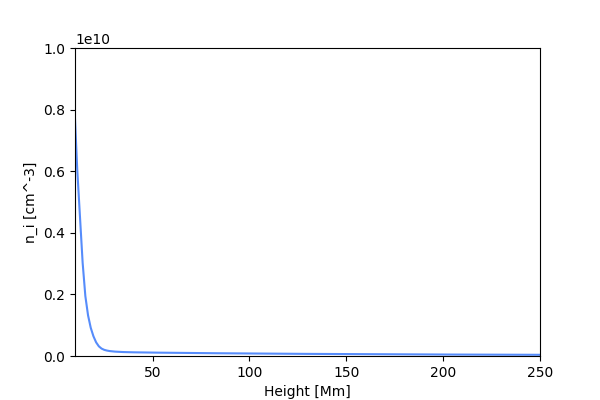

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(height, n_i[:, 0, -5], label='n_i')  # n_i near the North Pole
ax.set_ylabel('n_i [cm^-3]')

ax.set_xlabel('Height [Mm]')
ax.set_xlim([10, 250])
ax.set_ylim(0, 1e10)

plt.show()

In [17]:
plt.close(fig)